# Tarea final
#### Teoría de Grafos 
### Vazquez Zuloeta Samantha 

##### Red Erdon-Renyi

In [31]:
#Importamos bibliotecas
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

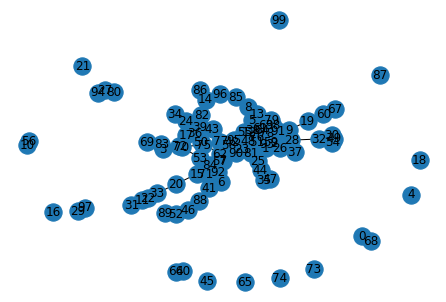

In [70]:
#Creamos los grafos - uno por tipo de atque o error
G=nx.erdos_renyi_graph(n=100,p=0.02,seed=40,directed=False)
nx.draw(G,with_labels=True)

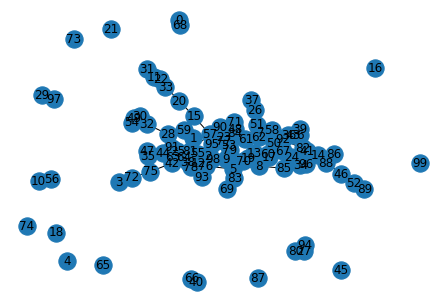

In [71]:
G1=nx.erdos_renyi_graph(n=100,p=0.02,seed=40,directed=False)
nx.draw(G1,with_labels=True)

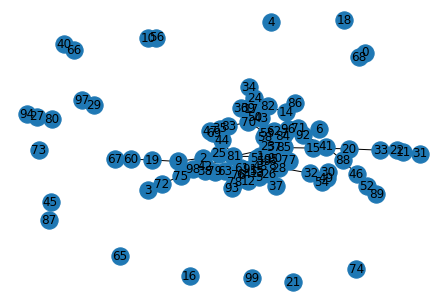

In [72]:
G2=nx.erdos_renyi_graph(n=100,p=0.02,seed=40,directed=False)
nx.draw(G2,with_labels=True)

In [73]:
#funicón para calcular la longitud característica
def long(grafo):
    long=[]
    Subgrafos = [grafo.subgraph(c).copy() for c in nx.connected_components(grafo)]
    longitudes=[]
    for i in range(len(Subgrafos)):
        longitudes.append(nx.average_shortest_path_length(Subgrafos[i]))
    long.append(np.mean(longitudes))   
    return long


In [74]:
#Ataque por grado
tamaño_componente_gig=[]
porcentaje_ataque=[]
coeficiente_ag=[]
eficiencia=[]
longitud=[]
componente_gigante = max(nx.connected_components(G), key=len)
tamaño_componente_gig.append(len(componente_gigante))
porcentaje_ataque.append(0)
coeficiente_ag.append(nx.average_clustering(G))
eficiencia.append(nx.global_efficiency(G))
longitud.append(long(G))  
for i in range(1,81):
    grados=list(G.degree)
    g_max=idx, max_value= max(grados, key=lambda item: item[1])
    G.remove_node(g_max[0])
    porcentaje_ataque.append(i/100)
    componente_gigante = max(nx.connected_components(G), key=len)
    tamaño_componente_gig.append(len(componente_gigante))
    coeficiente_ag.append(nx.average_clustering(G))
    eficiencia.append(nx.global_efficiency(G))
    longitud.append(long(G))

In [75]:
#Error aleatorio
tamaño_componente_gig1=[]
porcentaje_ataque=[]
coeficiente_ag1=[]
eficiencia1=[]
longitud1=[]
componente_gigante1 = max(nx.connected_components(G1), key=len)
tamaño_componente_gig1.append(len(componente_gigante1))
porcentaje_ataque.append(0)
coeficiente_ag1.append(nx.average_clustering(G1))
eficiencia1.append(nx.global_efficiency(G1))
longitud1.append(long(G1))
for i in range(80):
    nodo=np.random.choice(G1)
    G1.remove_node(nodo)
    porcentaje_ataque.append(i/100)
    componente_gigante1 = max(nx.connected_components(G1), key=len)
    tamaño_componente_gig1.append(len(componente_gigante1))
    coeficiente_ag1.append(nx.average_clustering(G1))
    eficiencia1.append(nx.global_efficiency(G1))
    longitud1.append(long(G1))

In [76]:
#Ataque por intermediación
tamaño_componente_gig2=[]
porcentaje_ataque=[]
coeficiente_ag2=[]
eficiencia2=[]
longitud2=[]
componente_gigante2 = max(nx.connected_components(G2), key=len)
tamaño_componente_gig2.append(len(componente_gigante2))
porcentaje_ataque.append(0)
coeficiente_ag2.append(nx.average_clustering(G2))
eficiencia2.append(nx.global_efficiency(G2))
longitud2.append(long(G2))
for i in range(80):
    intermediacion=nx.betweenness_centrality(G2, normalized=False)
    int_max=max(intermediacion.values())
    valores=list(intermediacion.values())
    nodos=list(intermediacion.keys())
    indice_valor=valores.index(int_max)
    nodo=nodos[indice_valor]
    G2.remove_node(nodo)
    porcentaje_ataque.append(i/100)
    componente_gigante2 = max(nx.connected_components(G2), key=len)
    tamaño_componente_gig2.append(len(componente_gigante2))
    coeficiente_ag2.append(nx.average_clustering(G2))
    eficiencia2.append(nx.global_efficiency(G2))
    longitud2.append(long(G2))

Tamaño del componete gigante

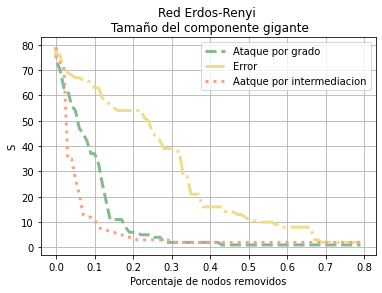

In [77]:
#Plots
plt.plot(porcentaje_ataque, tamaño_componente_gig, label='Ataque por grado', c='#83bb90', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque, tamaño_componente_gig1, label='Error', c='#f1dd88', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque, tamaño_componente_gig2, label='Aatque por intermediacion', c='#f7a482', linestyle='dotted', linewidth=3)
plt.title('Red Erdos-Renyi \n Tamaño del componente gigante')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('S')
plt.legend()
plt.grid()
plt.show()

Coeficiente de agrupamiento global

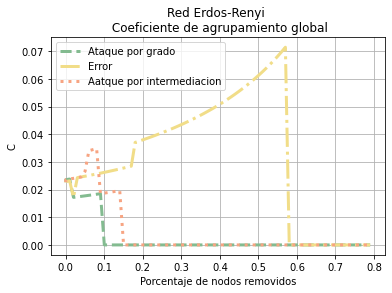

In [78]:
plt.plot(porcentaje_ataque, coeficiente_ag, label='Ataque por grado', c='#83bb90', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque, coeficiente_ag1, label='Error', c='#f1dd88', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque, coeficiente_ag2, label='Aatque por intermediacion', c='#f7a482', linestyle='dotted', linewidth=3)
plt.title('Red Erdos-Renyi \n Coeficiente de agrupamiento global')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('C')
plt.legend()
plt.grid()
plt.show()

Eficiencia

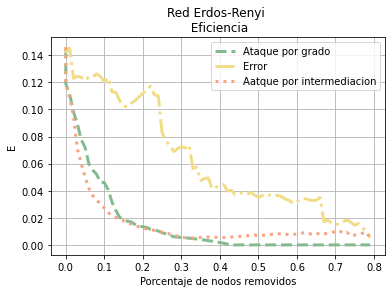

In [79]:
plt.plot(porcentaje_ataque, eficiencia, label='Ataque por grado', c='#83bb90', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque, eficiencia1, label='Error', c='#f1dd88', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque, eficiencia2, label='Aatque por intermediacion', c='#f7a482', linestyle='dotted', linewidth=3)
plt.title('Red Erdos-Renyi \n Eficiencia')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('E')
plt.legend()
plt.grid()
plt.show()

Longitud característica

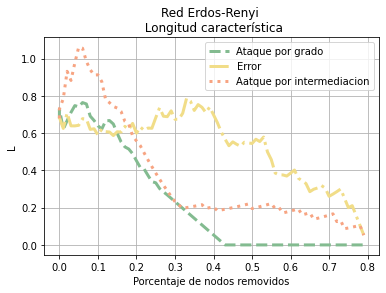

In [80]:
plt.plot(porcentaje_ataque, longitud, label='Ataque por grado', c='#83bb90', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque, longitud1, label='Error', c='#f1dd88', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque, longitud2, label='Aatque por intermediacion', c='#f7a482', linestyle='dotted', linewidth=3)
plt.title('Red Erdos-Renyi \n Longitud característica')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('L')
plt.legend()
plt.grid()
plt.show()

##### Modelo de Albert Barabasi

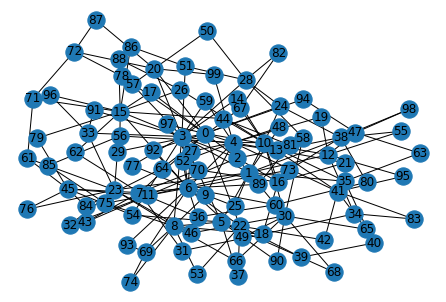

In [82]:
#Creamos los grafos - uno por tipo de atque o error
Gb=nx.barabasi_albert_graph(n=100,m=2)
nx.draw(Gb,with_labels=True)

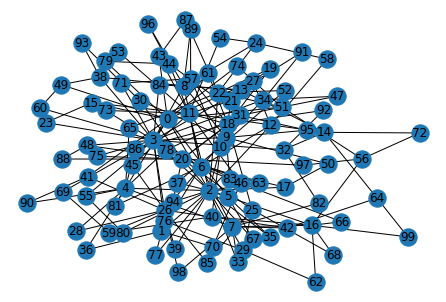

In [83]:
Gb1=nx.barabasi_albert_graph(n=100,m=2)
nx.draw(Gb1,with_labels=True)

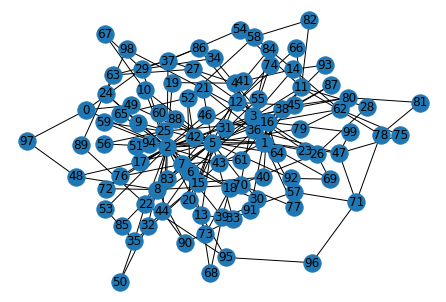

In [93]:
Gb2=nx.barabasi_albert_graph(n=100,m=2)
nx.draw(Gb2,with_labels=True)

In [86]:
#Ataque por grado
tamaño_componente_gig_b=[]
porcentaje_ataque_b=[]
coeficiente_ag_b=[]
eficiencia_b=[]
longitud_b=[]
componente_gigante_b = max(nx.connected_components(Gb), key=len)
tamaño_componente_gig_b.append(len(componente_gigante_b))
porcentaje_ataque_b.append(0)
coeficiente_ag_b.append(nx.average_clustering(Gb))
eficiencia_b.append(nx.global_efficiency(Gb))
longitud_b.append(long(Gb))  
for i in range(1,81):
    grados_b=list(Gb.degree)
    g_max_b=idx, max_value= max(grados_b, key=lambda item: item[1])
    Gb.remove_node(g_max_b[0])
    porcentaje_ataque_b.append(i/100)
    componente_gigante_b = max(nx.connected_components(Gb), key=len)
    tamaño_componente_gig_b.append(len(componente_gigante_b))
    coeficiente_ag_b.append(nx.average_clustering(Gb))
    eficiencia_b.append(nx.global_efficiency(Gb))
    longitud_b.append(long(Gb))

In [87]:
#Error aleatorio
tamaño_componente_gig1_b=[]
porcentaje_ataque_b=[]
coeficiente_ag1_b=[]
eficiencia1_b=[]
longitud1_b=[]
componente_gigante1_b = max(nx.connected_components(Gb1), key=len)
tamaño_componente_gig1_b.append(len(componente_gigante1_b))
porcentaje_ataque_b.append(0)
coeficiente_ag1_b.append(nx.average_clustering(Gb1))
eficiencia1_b.append(nx.global_efficiency(Gb1))
longitud1_b.append(long(Gb1))
for i in range(80):
    nodo_b=np.random.choice(Gb1)
    Gb1.remove_node(nodo_b)
    porcentaje_ataque_b.append(i/100)
    componente_gigante1_b = max(nx.connected_components(Gb1), key=len)
    tamaño_componente_gig1_b.append(len(componente_gigante1_b))
    coeficiente_ag1_b.append(nx.average_clustering(Gb1))
    eficiencia1_b.append(nx.global_efficiency(Gb1))
    longitud1_b.append(long(Gb1))

In [88]:
#Ataque por intermediación
tamaño_componente_gig2_b=[]
porcentaje_ataque_b=[]
coeficiente_ag2_b=[]
eficiencia2_b=[]
longitud2_b=[]
componente_gigante2_b = max(nx.connected_components(Gb2), key=len)
tamaño_componente_gig2_b.append(len(componente_gigante2_b))
porcentaje_ataque_b.append(0)
coeficiente_ag2_b.append(nx.average_clustering(Gb2))
eficiencia2_b.append(nx.global_efficiency(Gb2))
longitud2_b.append(long(Gb2))
for i in range(80):
    intermediacion_b=nx.betweenness_centrality(Gb2, normalized=False)
    int_max_b=max(intermediacion_b.values())
    valores_b=list(intermediacion_b.values())
    nodos_b=list(intermediacion_b.keys())
    indice_valor_b=valores_b.index(int_max_b)
    nodo_b=nodos_b[indice_valor_b]
    Gb2.remove_node(nodo_b)
    porcentaje_ataque_b.append(i/100)
    componente_gigante2_b = max(nx.connected_components(Gb2), key=len)
    tamaño_componente_gig2_b.append(len(componente_gigante2_b))
    coeficiente_ag2_b.append(nx.average_clustering(Gb2))
    eficiencia2_b.append(nx.global_efficiency(Gb2))
    longitud2_b.append(long(Gb2))

Tamaño del componente gigante

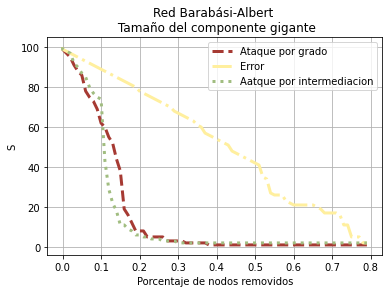

In [89]:
#Plots
plt.plot(porcentaje_ataque_b, tamaño_componente_gig_b, label='Ataque por grado', c='#a63a33', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque_b, tamaño_componente_gig1_b, label='Error', c='#ffef9e', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque_b, tamaño_componente_gig2_b, label='Aatque por intermediacion', c='#a1bd80', linestyle='dotted', linewidth=3)
plt.title('Red Barabási-Albert \n Tamaño del componente gigante')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('S')
plt.legend()
plt.grid()
plt.show()

Coeficiente de agrupamiento global

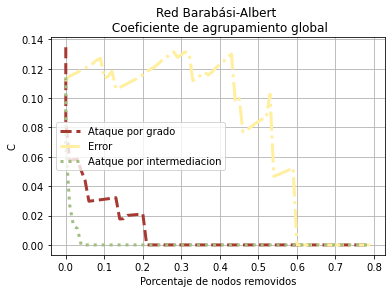

In [90]:
plt.plot(porcentaje_ataque_b, coeficiente_ag_b, label='Ataque por grado', c='#a63a33', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque_b, coeficiente_ag1_b, label='Error', c='#ffef9e', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque_b, coeficiente_ag2_b, label='Aatque por intermediacion', c='#a1bd80', linestyle='dotted', linewidth=3)
plt.title('Red Barabási-Albert \n Coeficiente de agrupamiento global')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('C')
plt.legend()
plt.grid()
plt.show()

Eficiencia

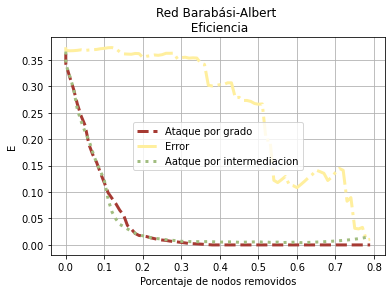

In [91]:
plt.plot(porcentaje_ataque_b, eficiencia_b, label='Ataque por grado', c='#a63a33', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque_b, eficiencia1_b, label='Error', c='#ffef9e', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque_b, eficiencia2_b, label='Aatque por intermediacion', c='#a1bd80', linestyle='dotted', linewidth=3)
plt.title('Red Barabási-Albert \n Eficiencia')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('E')
plt.legend()
plt.grid()
plt.show()

Longitud característica

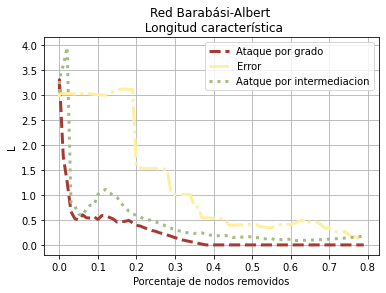

In [92]:
plt.plot(porcentaje_ataque_b, longitud_b, label='Ataque por grado', c='#a63a33', linestyle='dashed', linewidth=3)
plt.plot(porcentaje_ataque_b, longitud1_b, label='Error', c='#ffef9e', linestyle='dashdot', linewidth=3)
plt.plot(porcentaje_ataque_b, longitud2_b, label='Aatque por intermediacion', c='#a1bd80', linestyle='dotted', linewidth=3)
plt.title('Red Barabási-Albert \n Longitud característica')
plt.xlabel('Porcentaje de nodos removidos')
plt.ylabel('L')
plt.legend()
plt.grid()
plt.show()